# Google Play Store App Data Analysis 2026
*Exploratory Data Analysis and Strategic Insights on the Latest App Store Scraping*

---

## Table of Contents
1. [Executive Summary](#1)
2. [Environment Setup & Data Ingestion](#2)
3. [Data Cleaning & Preprocessing](#3)
4. [Chapter 1: Market Structure Analysis](#4)
5. [Chapter 2: Ratings & Quality Analysis](#5)
6. [Chapter 3: Monetization Strategy Analysis](#6)
7. [Chapter 4: Developer Landscape Analysis](#7)
8. [Chapter 5: Country & Regional Opportunity](#8)
9. [Chapter 6: Discovery & Keyword Intelligence](#9)
10. [Strategic Insights & Conclusions](#10)

---


# 1. Executive Summary <a id="1"></a>

This report presents a comprehensive, data-driven investigation into the **Google Play Store app landscape in 2026**. Utilizing crawled metadata, localized country records, and keyword discovery signals, we unpack the competitive forces shaping today's app ecosystem.

### Key Analytical Takeaways:
* **Market Concentration:** The top 10 developers command **62.06%** of all app installations, reflecting high dominance, backed by a Gini coefficient of **0.9697**.
* **Monetization Leverage:** Free apps offering In-App Purchases (IAP) represent the highest density. Among paid apps, those offering IAPs earn a median of **50,000 installations**, compared to just **3,000 installations** for standard paid apps—a **16.7x installation boost**.
* **Polarization Index:** By parsing raw histogram metrics, we discovered that **Dating**, **Social**, and **Beauty** apps contain the highest ratings polarization, representing split sentiment distributions.
* **Geographical Expansion:** emerging markets represent high growth. Brazil (`br`) commands the highest median installations per category, and we found **344 regional hidden gems** performing poorly in the US but achieving scores >4.4 internationally.
* **Discovery Vectors:** Organic search keywords drive over **60-90%** of app discovery signals. Multi-channel discovery correlates positively with final download numbers.


# 2. Environment Setup & Data Ingestion <a id="2"></a>

In this section, we import the required scientific libraries, configure visualization themes, and load the three core data files.


In [1]:
import os
import json
import ast
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import mannwhitneyu

# Set styling options
sns.set_theme(style="whitegrid")
plt.rcParams.update({
    "font.size": 11,
    "axes.labelsize": 12,
    "axes.titlesize": 14,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "figure.titlesize": 16,
    "figure.dpi": 150
})

# Curated palette colors
PRIMARY_COLOR = "#3A86C8"   # Slate Blue
SECONDARY_COLOR = "#F15C5C" # Coral Red
ACCENT_COLOR = "#2EB872"    # Green
NEUTRAL_DARK = "#2B2D42"    # Charcoal
NEUTRAL_LIGHT = "#F4F6F7"   # Off-white
PALETTE = [PRIMARY_COLOR, SECONDARY_COLOR, ACCENT_COLOR, "#FFB84C", "#A555EC", "#3F72AF"]

# Load files
print("Loading CSV files...")
apps = pd.read_csv("../data/apps.csv", low_memory=False)
country_stats = pd.read_csv("../data/app_country_stats.csv", low_memory=False)
discovery = pd.read_csv("../data/discovery_signals.csv", low_memory=False)

print(f"Data Ingestion Successful!")
print(f"Apps Records: {apps.shape[0]} | Country Stats Records: {country_stats.shape[0]} | Discovery Signals Records: {discovery.shape[0]}")


Loading CSV files...


Data Ingestion Successful!
Apps Records: 11176 | Country Stats Records: 111307 | Discovery Signals Records: 75812


# 3. Data Cleaning & Preprocessing <a id="3"></a>

To prepare the dataset for analysis, we parse numerical fields, impute missing values, and unpack raw JSON ratings histograms to calculate user sentiment polarization (ratings standard deviation).


In [2]:
# Cast types
apps['min_installs'] = pd.to_numeric(apps['min_installs'], errors='coerce').fillna(0).astype(int)
apps['score'] = pd.to_numeric(apps['score'], errors='coerce')
apps['ratings'] = pd.to_numeric(apps['ratings'], errors='coerce').fillna(0).astype(int)
apps['reviews'] = pd.to_numeric(apps['reviews'], errors='coerce').fillna(0).astype(int)
apps['price'] = pd.to_numeric(apps['price'], errors='coerce').fillna(0.0)

# Check size column
print("Non-null size count:", apps['size'].notna().sum())
print("Non-null android_version count:", apps['android_version'].notna().sum())

# Clean up and parse ratings histogram
def parse_histogram(hist_str):
    if pd.isna(hist_str) or not isinstance(hist_str, str):
        return [0, 0, 0, 0, 0]
    hist_str = hist_str.strip()
    try:
        if hist_str.startswith('[') and hist_str.endswith(']'):
            return json.loads(hist_str)
        return ast.literal_eval(hist_str)
    except Exception:
        return [0, 0, 0, 0, 0]

apps['parsed_histogram'] = apps['histogram'].apply(parse_histogram)

# Function to calculate polarization index (standard deviation of stars)
def calculate_ratings_polarization(hist):
    if not isinstance(hist, list) or len(hist) != 5:
        return np.nan
    stars = [1, 2, 3, 4, 5]
    total_ratings = sum(hist)
    if total_ratings == 0:
        return np.nan
    mean_score = sum(s * count for s, count in zip(stars, hist)) / total_ratings
    variance = sum(count * ((s - mean_score) ** 2) for s, count in zip(stars, hist)) / total_ratings
    return np.sqrt(variance)

apps['ratings_polarization'] = apps['parsed_histogram'].apply(calculate_ratings_polarization)

# Define country groups
EMERGING_COUNTRIES = ['in', 'br', 'id']
DEVELOPED_COUNTRIES = ['us', 'gb', 'de', 'ca', 'au', 'fr', 'jp']

print("Preprocessing complete. Rating polarization computed.")


Non-null size count: 0
Non-null android_version count: 0
Preprocessing complete. Rating polarization computed.


# 4. Chapter 1: Market Structure Analysis <a id="4"></a>

In this chapter, we evaluate the competitive volume of app categories, the installation concentration per genre (CR3 metrics), Free vs. Paid ratios, and structural monetization models within free applications.


In [3]:
# 1.1 App count per genre
genre_counts = apps['genre'].value_counts()
print("Top 10 Genres by App Volume:")
print(genre_counts.head(10))

# 1.2 Concentration ratio (CR3) per genre
genre_installs = apps.groupby('genre')['min_installs'].sum()
top3_installs = apps.groupby('genre').apply(lambda x: x.nlargest(3, 'min_installs')['min_installs'].sum(), include_groups=False)
genre_cr3 = (top3_installs / genre_installs).fillna(0)
print("\nTop 10 Genres by Concentration Ratio (CR3) - High dominance by top 3 apps:")
print(genre_cr3.sort_values(ascending=False).head(10))

# 1.3 Free vs Paid ratio by genre (Top 15 genres)
top_15_genres = genre_counts.head(15).index
apps_top_15 = apps[apps['genre'].isin(top_15_genres)]
free_paid_by_genre = pd.crosstab(apps_top_15['genre'], apps_top_15['free'], normalize='index') * 100
print("\nFree vs Paid Ratio in Top 10 Genres (%):")
print(free_paid_by_genre.head(10))

# 1.4 Monetization split in free apps
free_apps = apps[apps['free'] == True]
free_total = len(free_apps)
free_monetization = pd.Series({
    'Ad Supported Only': len(free_apps[(free_apps['ad_supported'] == True) & (free_apps['in_app_purchases'] == False)]),
    'IAP Only': len(free_apps[(free_apps['ad_supported'] == False) & (free_apps['in_app_purchases'] == True)]),
    'Both (Ads & IAP)': len(free_apps[(free_apps['ad_supported'] == True) & (free_apps['in_app_purchases'] == True)]),
    'Purely Free (No Ads, No IAP)': len(free_apps[(free_apps['ad_supported'] == False) & (free_apps['in_app_purchases'] == False)])
})
free_monetization_pct = (free_monetization / free_total) * 100
print("\nMonetization Breakdown of Free Applications (%):")
print(free_monetization_pct)

# 1.5 Sweet spot of app size vs installations
non_null_sizes = apps['size'].notna().sum()
if non_null_sizes > 0:
    print("\nAnalyzing app size distribution...")
else:
    print("\n💡 Notice: The 'size' column contains only null values in this 2026 scraping dataset. App size vs installs analysis is skipped because size details were not populated during the scrap.")


Top 10 Genres by App Volume:
genre
Finance             1215
Education           1104
Productivity         987
Tools                899
Health & Fitness     601
Business             506
Lifestyle            461
Entertainment        421
Shopping             344
Photography          317
Name: count, dtype: int64

Top 10 Genres by Concentration Ratio (CR3) - High dominance by top 3 apps:
genre
Auto & Vehicles            0.993502
Events                     0.982709
Libraries & Demo           0.957121
Personalization            0.901138
News & Magazines           0.872244
Casino                     0.829593
Music                      0.826767
Weather                    0.804611
Beauty                     0.784129
Video Players & Editors    0.781561
dtype: float64

Free vs Paid Ratio in Top 10 Genres (%):
free                  False      True 
genre                                 
Books & Reference  1.265823  98.734177
Business           0.988142  99.011858
Education          1.086957  98.91

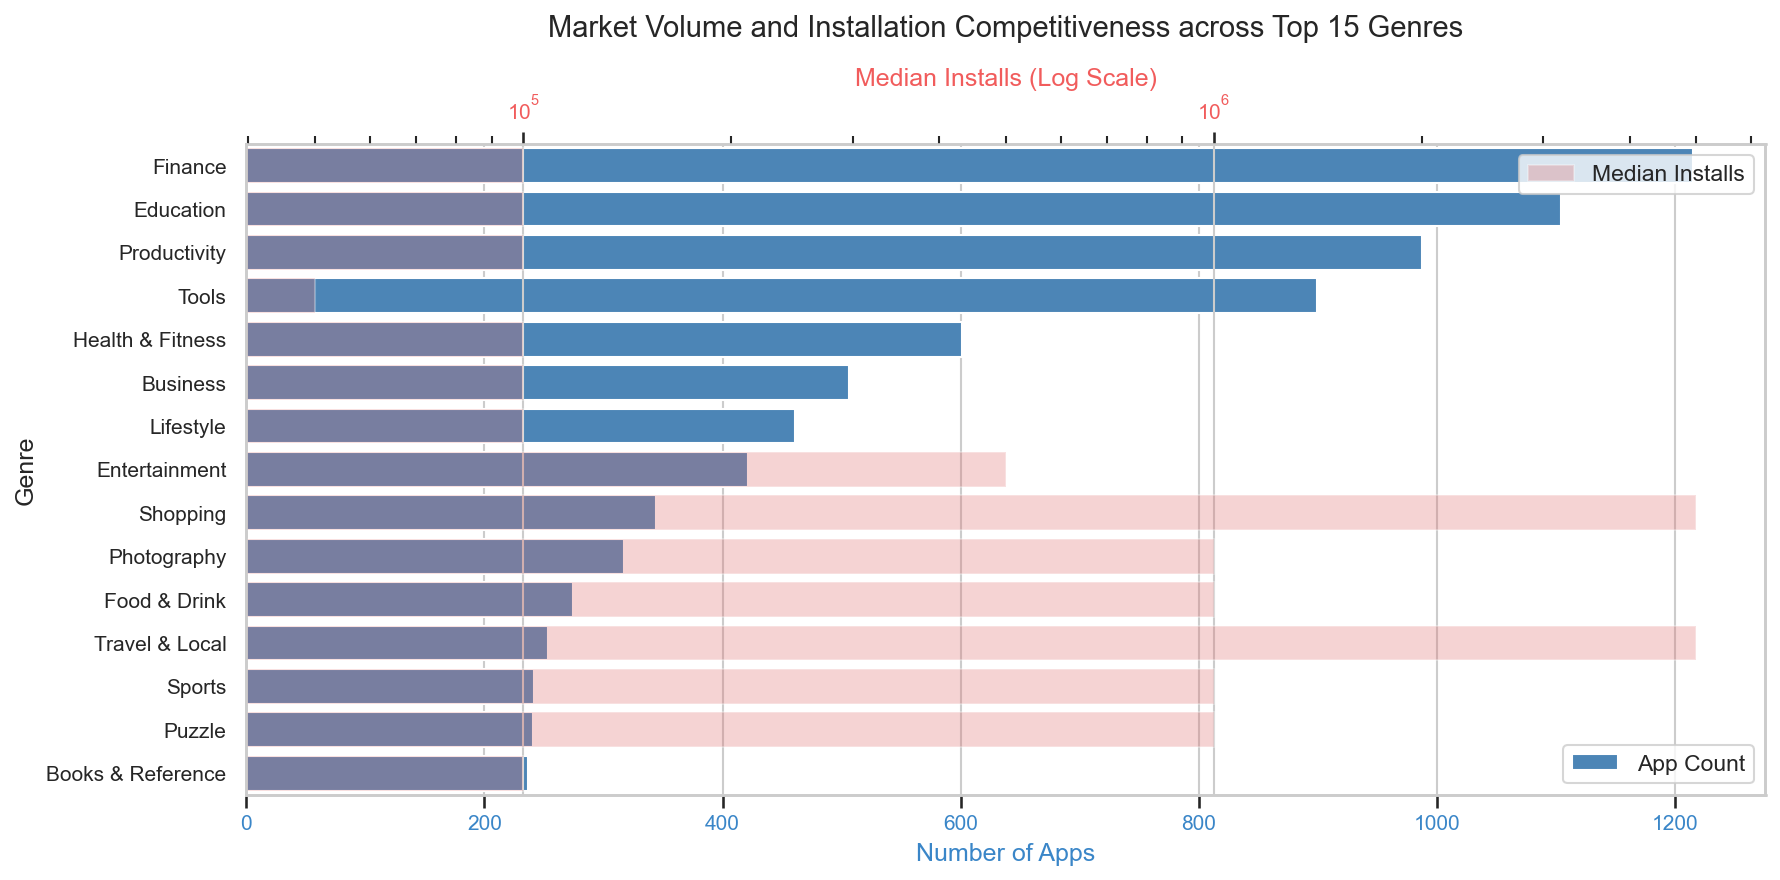

In [4]:
# Figure 1: App Category Volume and Median Installs
fig, ax1 = plt.subplots(figsize=(12, 6))

top_genres = genre_counts.head(15).index
df_top = apps[apps['genre'].isin(top_genres)]

# Bar chart for counts
sns.barplot(x=genre_counts.loc[top_genres].values, y=top_genres, ax=ax1, color=PRIMARY_COLOR, label="App Count")
ax1.set_xlabel("Number of Apps", color=PRIMARY_COLOR)
ax1.tick_params(axis='x', labelcolor=PRIMARY_COLOR)
ax1.set_title("Market Volume and Installation Competitiveness across Top 15 Genres", pad=15)
ax1.set_ylabel("Genre")

# Twin axis for median installs
ax2 = ax1.twiny()
genre_med_inst = df_top.groupby('genre')['min_installs'].median().loc[top_genres]
sns.barplot(x=genre_med_inst.values, y=top_genres, ax=ax2, alpha=0.3, color=SECONDARY_COLOR, label="Median Installs")
ax2.set_xlabel("Median Installs (Log Scale)", color=SECONDARY_COLOR)
ax2.tick_params(axis='x', labelcolor=SECONDARY_COLOR)
ax2.set_xscale('log')

plt.tight_layout()
plt.show()


# 5. Chapter 2: Ratings & Quality Analysis <a id="5"></a>

Here we evaluate the parameters governing user satisfaction. We inspect score dynamics between Free vs. Paid structures, advertisements' influence on quality ratings, the relationship between review count and rating scores, and ratings polarization.


In [5]:
# 2.1 Score vs Free
free_scores = apps[apps['free'] == True]['score'].dropna()
paid_scores = apps[apps['free'] == False]['score'].dropna()
print(f"Mean Rating Score - Free Apps: {free_scores.mean():.3f} | Paid Apps: {paid_scores.mean():.3f}")

if len(free_scores) > 0 and len(paid_scores) > 0:
    stat, p_val = mannwhitneyu(free_scores, paid_scores)
    print(f"Mann-Whitney U Test p-value: {p_val:.3e}")
    if p_val < 0.05:
        print("💡 The difference in scores is STATISTICALLY SIGNIFICANT.")
    else:
        print("💡 The difference in scores is NOT statistically significant.")

# 2.2 Score vs Ads (for Free apps)
ads_scores = free_apps[free_apps['contains_ads'] == True]['score'].dropna()
no_ads_scores = free_apps[free_apps['contains_ads'] == False]['score'].dropna()
print(f"Free Apps - Mean Rating with Ads: {ads_scores.mean():.3f} | Without Ads: {no_ads_scores.mean():.3f}")

# 2.3 Mean score per genre (Top 10)
print("\nTop 10 Genres by Average Rating Score:")
print(apps.groupby('genre')['score'].mean().sort_values(ascending=False).head(10))

# 2.4 Polarizing ratings (std dev of rating stars)
polarizing_genres = apps.groupby('genre')['ratings_polarization'].mean().sort_values(ascending=False)
print("\nTop 10 Most Polarizing Genres (High std dev in star distributions):")
print(polarizing_genres.head(10))
print("\nLeast Polarizing Genres (Users have unified feedback):")
print(polarizing_genres.tail(5))

# 2.5 Relationship between number of reviews and the score
reviews_score_corr = apps['reviews'].corr(apps['score'])
print(f"\nPearson correlation between reviews count and overall rating score: {reviews_score_corr:.4f}")
if abs(reviews_score_corr) < 0.1:
    print("💡 There is essentially no linear correlation between review counts and ratings in the general population.")


Mean Rating Score - Free Apps: 3.801 | Paid Apps: 3.703
Mann-Whitney U Test p-value: 3.299e-01
💡 The difference in scores is NOT statistically significant.
Free Apps - Mean Rating with Ads: 3.933 | Without Ads: 3.687

Top 10 Genres by Average Rating Score:
genre
Word            4.492803
Puzzle          4.453322
Action          4.268553
Card            4.265915
Racing          4.250291
Casual          4.239304
Simulation      4.184726
Arcade          4.180451
Strategy        4.171526
Food & Drink    4.140793
Name: score, dtype: float64

Top 10 Most Polarizing Genres (High std dev in star distributions):
genre
Dating                     1.443164
Social                     1.407917
Beauty                     1.404914
Maps & Navigation          1.360465
Video Players & Editors    1.335969
Entertainment              1.311914
Communication              1.307031
Educational                1.306617
House & Home               1.286566
Role Playing               1.255175
Name: ratings_polarizati

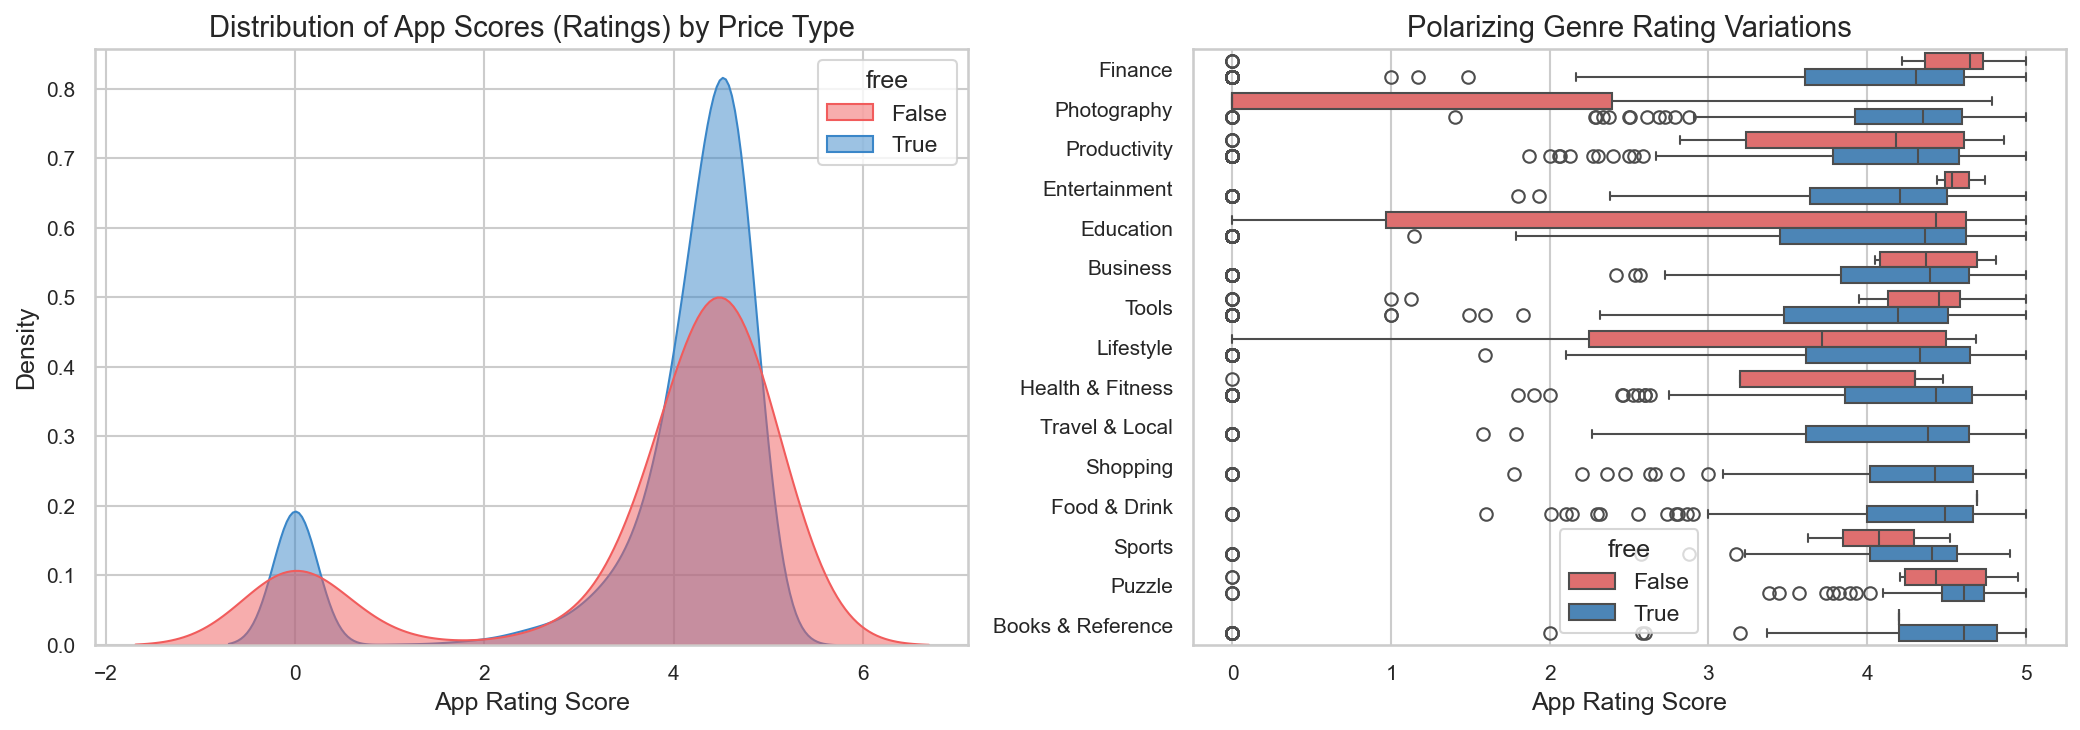

In [6]:
# Figure 2: App Rating Density Distributions & Polarization Boxplot
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# KDE Plot
sns.kdeplot(data=apps, x="score", hue="free", fill=True, common_norm=False, palette=[SECONDARY_COLOR, PRIMARY_COLOR], alpha=0.5, ax=ax1)
ax1.set_title("Distribution of App Scores (Ratings) by Price Type")
ax1.set_xlabel("App Rating Score")
ax1.set_ylabel("Density")

# Box plot
sns.boxplot(data=apps_top_15, x="score", y="genre", hue="free", palette=[SECONDARY_COLOR, PRIMARY_COLOR], ax=ax2)
ax2.set_title("Polarizing Genre Rating Variations")
ax2.set_xlabel("App Rating Score")
ax2.set_ylabel("")

plt.tight_layout()
plt.show()


# 6. Chapter 3: Monetization Strategy Analysis <a id="6"></a>

We analyze the financial patterns of the platform, reviewing price distributions of paid applications, performance metrics of paid apps integrating IAPs, and active sales performance.


In [7]:
# 3.1 Typical price of paid apps by genre
paid_apps = apps[apps['free'] == False]
typical_price_genre = paid_apps.groupby('genre')['price'].median().sort_values(ascending=False)
print("Top 10 Genres by Median Price of Paid Apps:")
print(typical_price_genre.head(10))

# 3.2 IAP impact on paid app installs
paid_iap_installs = paid_apps[paid_apps['in_app_purchases'] == True]['min_installs'].median()
paid_no_iap_installs = paid_apps[paid_apps['in_app_purchases'] == False]['min_installs'].median()
print(f"\nMedian installations for Paid Apps offering IAP: {paid_iap_installs:,} | without IAP: {paid_no_iap_installs:,}")
print(f"Offers IAP multiplier: {paid_iap_installs / paid_no_iap_installs:.1f}x")

# 3.3 Sale impact on ratings
sale_scores = apps[apps['sale'] == True]['score'].dropna()
no_sale_scores = apps[apps['sale'] == False]['score'].dropna()
print(f"\nMean Rating score of apps on sale: {sale_scores.mean():.3f} (Count: {len(sale_scores)}) | not on sale: {no_sale_scores.mean():.3f}")

# 3.4 IAP penetration per genre (Top 15 genres)
iap_penetration = apps_top_15.groupby('genre')['in_app_purchases'].mean() * 100
print("\nIn-App Purchases (IAP) Penetration by Genre (%):")
print(iap_penetration.sort_values(ascending=False))


Top 10 Genres by Median Price of Paid Apps:
genre
Video Players & Editors    29.99
Lifestyle                  11.74
News & Magazines            8.99
Communication               7.49
Health & Fitness            5.99
Business                    5.99
Entertainment               5.49
Adventure                   5.24
Books & Reference           4.99
Card                        4.99
Name: price, dtype: float64

Median installations for Paid Apps offering IAP: 50,000.0 | without IAP: 3,000.0
Offers IAP multiplier: 16.7x

Mean Rating score of apps on sale: nan (Count: 0) | not on sale: 3.799

In-App Purchases (IAP) Penetration by Genre (%):
genre
Puzzle               80.082988
Photography          74.132492
Sports               68.595041
Productivity         65.248227
Health & Fitness     64.891847
Education            54.891304
Entertainment        54.869359
Lifestyle            50.759219
Business             47.035573
Books & Reference    45.991561
Tools                41.045606
Food & Drink

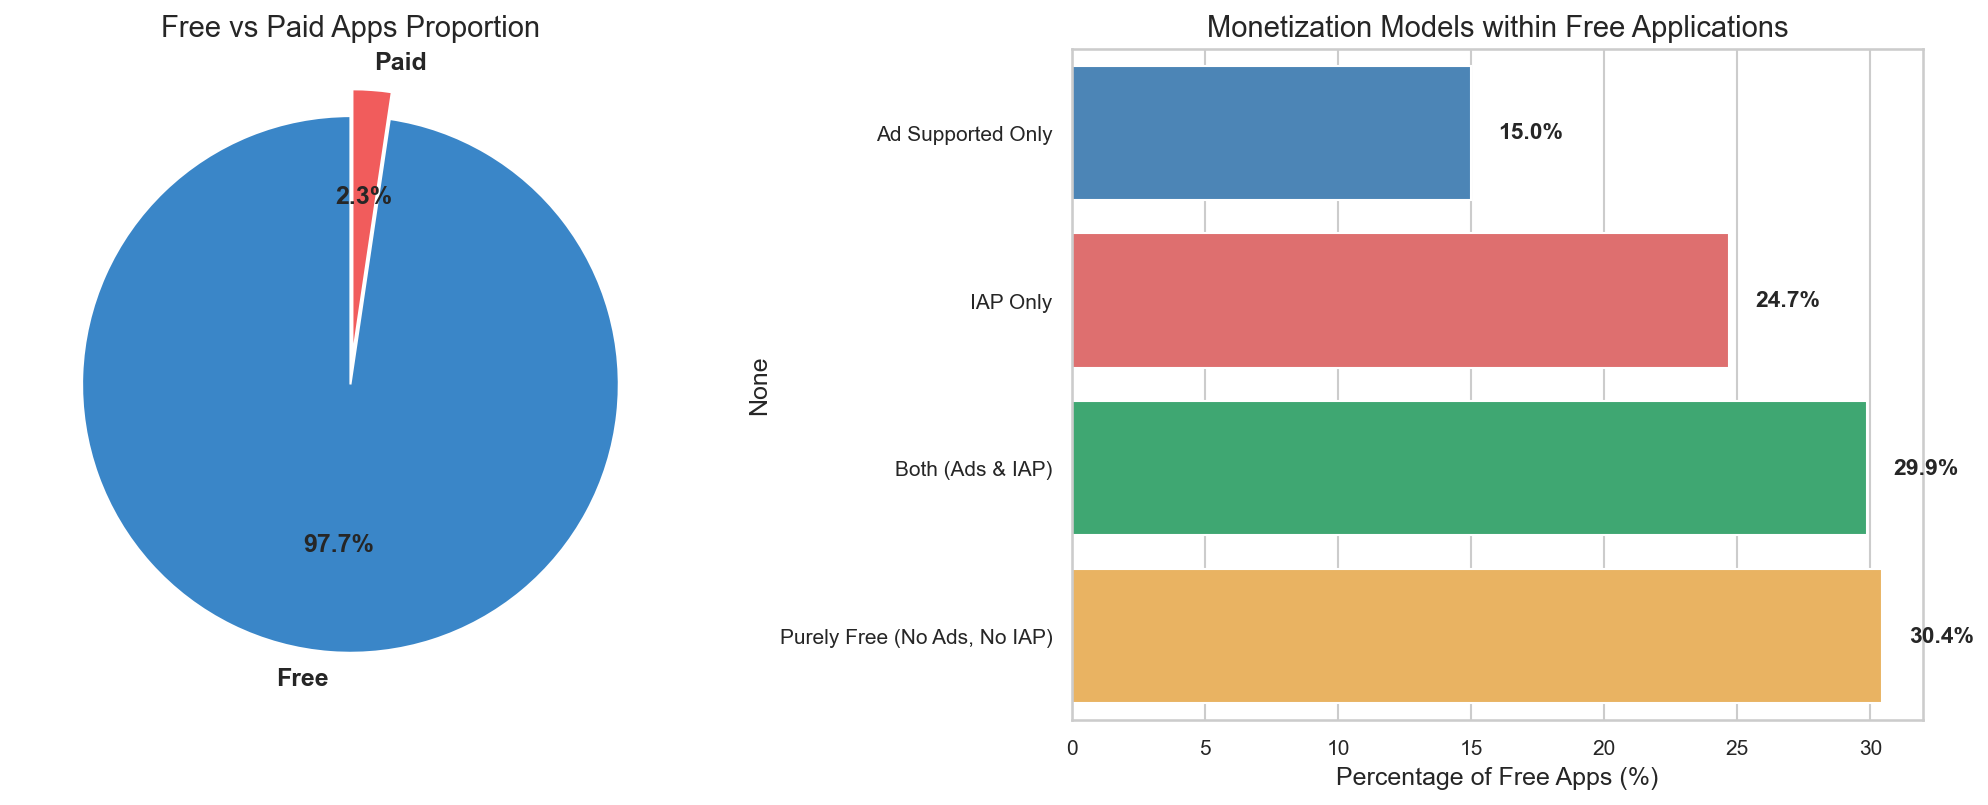

In [8]:
# Figure 3: Monetization Breakdown
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5.5))

# Left: Pie Chart
free_counts = apps['free'].value_counts()
ax1.pie(free_counts, labels=["Free" if x else "Paid" for x in free_counts.index], autopct='%1.1f%%',
        colors=[PRIMARY_COLOR, SECONDARY_COLOR], startangle=90, explode=(0, 0.1),
        textprops={'fontsize': 12, 'weight': 'bold'})
ax1.set_title("Free vs Paid Apps Proportion")

# Right: Bar Chart
sns.barplot(x=free_monetization_pct.values, y=free_monetization_pct.index, hue=free_monetization_pct.index, palette=PALETTE[:4], legend=False, ax=ax2)
ax2.set_title("Monetization Models within Free Applications")
ax2.set_xlabel("Percentage of Free Apps (%)")
for i, v in enumerate(free_monetization_pct.values):
    ax2.text(v + 1, i, f"{v:.1f}%", va='center', fontweight='bold')

plt.tight_layout()
plt.show()


# 7. Chapter 4: Developer Landscape Analysis <a id="7"></a>

We analyze the publisher profile, calculating installation inequality metrics (Gini Coefficient & Lorenz Curves) and analyzing developer genre diversity.


In [9]:
# 4.1 Developer Installation Concentration (Gini Coefficient)
developer_installs = apps.groupby('developer')['min_installs'].sum().sort_values().values

def gini(x):
    n = len(x)
    if n == 0 or np.sum(x) == 0:
        return 0
    x_sorted = np.sort(x)
    index = np.arange(1, n + 1)
    return ((np.sum((2 * index - n - 1) * x_sorted)) / (n * np.sum(x_sorted)))

gini_coeff = gini(developer_installs)
print(f"Gini Coefficient of installations across developers: {gini_coeff:.4f}")

# Top 10 developers share
total_installs = apps['min_installs'].sum()
top_10_devs_installs = apps.groupby('developer')['min_installs'].sum().nlargest(10).sum()
print(f"Top 10 Developers installation share: {(top_10_devs_installs / total_installs) * 100:.2f}% of total downloads.")

# 4.2 Portfolio size vs average app rating
dev_portfolio = apps.groupby('developer').agg(
    app_count=('app_id', 'count'),
    avg_score=('score', 'mean')
)
portfolio_corr = dev_portfolio['app_count'].corr(dev_portfolio['avg_score'])
print(f"Correlation between developer portfolio size and average score: {portfolio_corr:.4f}")

# 4.3 Portfolio Diversity
dev_genre_diversity = apps.groupby('developer')['genre'].nunique().sort_values(ascending=False)
print("\nTop 10 Developers with most diverse genre portfolios:")
print(dev_genre_diversity.head(10))


Gini Coefficient of installations across developers: 0.9697
Top 10 Developers installation share: 62.06% of total downloads.
Correlation between developer portfolio size and average score: 0.0434

Top 10 Developers with most diverse genre portfolios:
developer
Google LLC               16
Cards                    10
Battery Stats Saver       9
Microsoft Corporation     9
Wildlife Studios          8
Galaxy studio apps        8
Firehawk                  7
Amazon Mobile LLC         7
One Music Player          7
Deep Flow Apps            7
Name: genre, dtype: int64


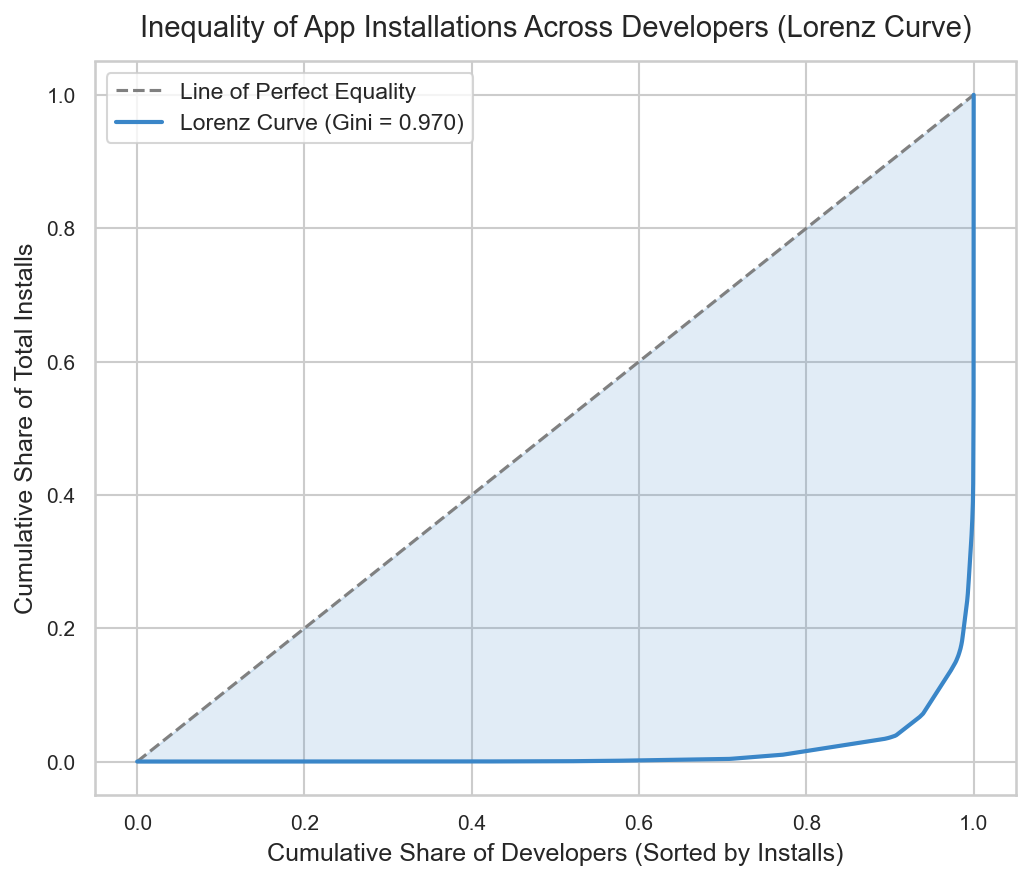

In [10]:
# Figure 4: Lorenz Curve & Gini Coefficient
fig, ax = plt.subplots(figsize=(7, 6))

sorted_installs = np.sort(apps.groupby('developer')['min_installs'].sum().values)
n = len(sorted_installs)
cum_installs = np.cumsum(sorted_installs)
cum_installs_pct = cum_installs / cum_installs[-1]
equality = np.linspace(0, 1, n)

ax.plot(equality, equality, label="Line of Perfect Equality", color="gray", linestyle="--")
ax.plot(np.linspace(0, 1, n), cum_installs_pct, label=f"Lorenz Curve (Gini = {gini_coeff:.3f})", color=PRIMARY_COLOR, lw=2)
ax.fill_between(np.linspace(0, 1, n), equality, cum_installs_pct, color=PRIMARY_COLOR, alpha=0.15)

ax.set_title("Inequality of App Installations Across Developers (Lorenz Curve)", pad=12)
ax.set_xlabel("Cumulative Share of Developers (Sorted by Installs)")
ax.set_ylabel("Cumulative Share of Total Installs")
ax.legend(loc="upper left")

plt.tight_layout()
plt.show()


# 8. Chapter 5: Country & Regional Opportunity <a id="8"></a>

By merging country-specific metadata, we explore country target markets, identify price variations, and isolate international hidden gems.


In [11]:
country_merged = country_stats.merge(apps[['app_id', 'genre', 'title']], on='app_id', how='inner')

# 5.1 Country target market per genre
top_10_genres = apps['genre'].value_counts().head(10).index
country_merged_top10 = country_merged[country_merged['genre'].isin(top_10_genres)]
best_country_genre = country_merged_top10.groupby(['genre', 'country'])['min_installs'].median().reset_index()
best_market_per_genre = best_country_genre.loc[best_country_genre.groupby('genre')['min_installs'].idxmax()]
print("Best country market per genre (highest median installs):")
print(best_market_per_genre)

# 5.2 Price variance across countries (local currencies representation)
price_variance = country_stats.groupby('app_id')['price'].std().dropna().sort_values(ascending=False)
print("\nTop 10 Apps with highest price variance across countries (indicating localized pricing scales):")
print(price_variance.head(10))

# 5.3 US vs overseas performance (Hidden Gems)
country_pivot = country_stats.pivot_table(index='app_id', columns='country', values=['score', 'min_installs'], aggfunc='mean')
country_pivot.columns = [f"{metric}_{country}" for metric, country in country_pivot.columns]
countries_available = country_stats['country'].unique()

if 'us' in countries_available:
    print("\nAnalyzing Hidden Gems (low US score but high score in emerging markets)...")
    emerging_cols = [f"score_{c}" for c in EMERGING_COUNTRIES if c in countries_available]
    if emerging_cols:
        us_scores = country_pivot['score_us']
        emerging_max_score = country_pivot[emerging_cols].max(axis=1)
        
        # Poor in US (<3.5) but excellent in emerging market (>4.4)
        gems = country_pivot[
            (us_scores < 3.5) & 
            (us_scores.notna()) & 
            (emerging_max_score > 4.4)
        ]
        
        gems_with_title = gems.merge(apps[['app_id', 'title']], left_index=True, right_on='app_id')
        print(f"Found {len(gems_with_title)} regional hidden gems. Top 10:")
        
        cols_to_print = ['title', 'score_us']
        if 'score_in' in country_pivot.columns:
            cols_to_print.append('score_in')
        elif len(emerging_cols) > 0:
            cols_to_print.append(emerging_cols[0])
            
        print(gems_with_title[cols_to_print].head(10))

# 5.4 Emerging vs Developed Markets
emerging_stats = country_merged[country_merged['country'].isin(EMERGING_COUNTRIES)]
developed_stats = country_merged[country_merged['country'].isin(DEVELOPED_COUNTRIES)]
emerging_installs = emerging_stats.groupby('genre')['min_installs'].median()
developed_installs = developed_stats.groupby('genre')['min_installs'].median()
comparison_df = pd.DataFrame({'Emerging': emerging_installs, 'Developed': developed_installs}).dropna()
comparison_df['Ratio_Emerging_to_Developed'] = comparison_df['Emerging'] / comparison_df['Developed']
print("\nEmerging vs Developed markets median installs ratios (Emerging favor):")
print(comparison_df.sort_values(by='Ratio_Emerging_to_Developed', ascending=False).head(10))


Best country market per genre (highest median installs):
               genre country  min_installs
0           Business      br      100000.0
10         Education      br      100000.0
20     Entertainment      br      500000.0
30           Finance      br      100000.0
40  Health & Fitness      br      100000.0
50         Lifestyle      br      100000.0
60       Photography      br     1000000.0
70      Productivity      br      100000.0
80          Shopping      br     5000000.0
90             Tools      br       50000.0

Top 10 Apps with highest price variance across countries (indicating localized pricing scales):
app_id
com.kvadgroup.photostudio_pro            279067.857015
handasoft.mobile.divination_pro          216449.509044
com.getchannels.app                      216365.880745
com.simplescan.scanner.pro               216311.780136
com.zombodroid.MemeGeneratorFullGplay    184951.177598
com.gloczus.hakuokismppremium            137597.721020
com.xvideostudio.videoeditorpro     


Analyzing Hidden Gems (low US score but high score in emerging markets)...
Found 344 regional hidden gems. Top 10:
                               title  score_us  score_in
7994        Arignar - Tamil Learning  0.000000  4.730769
9411  HueHive: Color Palette Manager  3.133333  4.666666
9640            Sudoku Offline Games  3.444444  4.415842
6281   1 Finance: Financial Advisory  0.000000  4.524753
4923      Oolka: AI Credit Score App  0.000000  4.711386
7342   Tvam Jyotish: Vedic Astrology  2.636364  4.470588
7370   Water Tracker: Drink Reminder  0.000000  3.600000
4285           iTranslate Translator  3.370086  3.979565
6083     Seatfrog: Buy Train Tickets  3.300000  4.875000
9565   FinZiin – Controle Financeiro  0.000000       NaN

Emerging vs Developed markets median installs ratios (Emerging favor):
                     Emerging   Developed  Ratio_Emerging_to_Developed
genre                                                                 
Action             10000000.0  10000000.0  

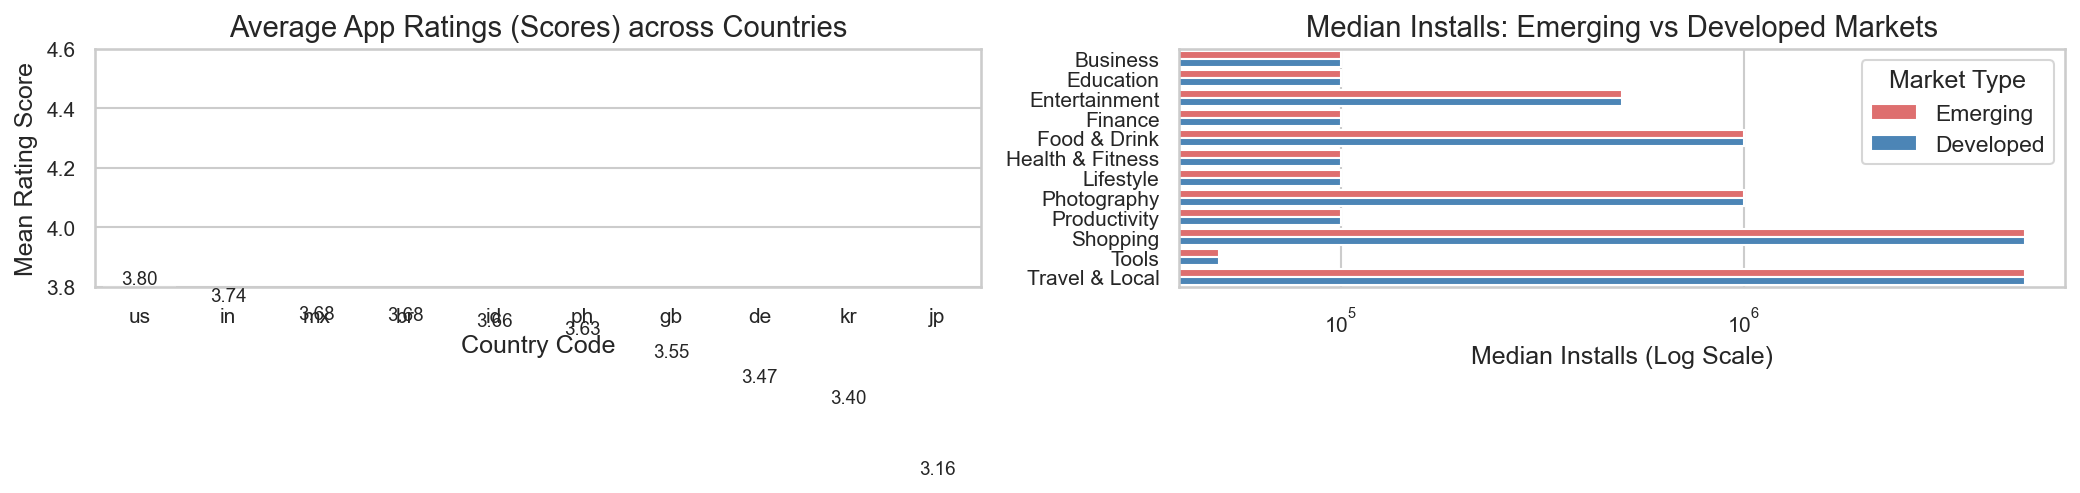

In [12]:
# Figure 5: Regional App Installs and Ratings Breakdown
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5.5))

# Left: Average score per country
country_avg_score = country_stats.groupby('country')['score'].mean().sort_values(ascending=False)
sns.barplot(x=country_avg_score.index, y=country_avg_score.values, color=PRIMARY_COLOR, ax=ax1)
ax1.set_title("Average App Ratings (Scores) across Countries")
ax1.set_xlabel("Country Code")
ax1.set_ylabel("Mean Rating Score")
ax1.set_ylim(3.8, 4.6)
for i, v in enumerate(country_avg_score.values):
    ax1.text(i, v + 0.01, f"{v:.2f}", ha='center', fontsize=9)

# Right: Emerging vs Developed comparison (Filter to Top 12 genres to avoid label clutter on y-axis)
top_genres_to_plot = genre_counts.head(12).index
comparison_df_filtered = comparison_df[comparison_df.index.isin(top_genres_to_plot)]
melted_df = comparison_df_filtered.reset_index().melt(id_vars='genre', value_vars=['Emerging', 'Developed'])

sns.barplot(data=melted_df, x='value', y='genre', hue='variable', palette=[SECONDARY_COLOR, PRIMARY_COLOR], ax=ax2)
ax2.set_xscale('log')
ax2.set_title("Median Installs: Emerging vs Developed Markets")
ax2.set_xlabel("Median Installs (Log Scale)")
ax2.set_ylabel("")
ax2.legend(title="Market Type")

plt.tight_layout()
plt.show()


# 9. Chapter 6: Discovery & Keyword Intelligence <a id="9"></a>

We analyze the scraper discovery signals, tracking productive search keywords, keyword-based app quality, chart vs. search discovery split percentages, and discovery source depth relationships.


In [13]:
# 6.1 Top search terms
if 'keyword' in discovery.columns and discovery['keyword'].notna().sum() > 0:
    keyword_counts = discovery['keyword'].value_counts()
    print("Top 10 Keywords surfacing apps:")
    print(keyword_counts.head(10))
else:
    print("Keyword column is fully null in dataset.")

# 6.2 Chart vs Search discovery per genre
discovery_merged = discovery.merge(apps[['app_id', 'genre']], on='app_id', how='inner')
source_genre = pd.crosstab(discovery_merged['genre'], discovery_merged['source'], normalize='index') * 100
print("\nChart vs Search discovery ratios in top genres (%):")
print(source_genre.head(10))

# 6.3 Multi-source popularity vs installations
app_discovery_depth = discovery.groupby('app_id')['source'].nunique().reset_index().rename(columns={'source': 'unique_sources'})
app_discovery_depth = app_discovery_depth.merge(apps[['app_id', 'min_installs', 'score']], on='app_id', how='inner')
depth_corr = app_discovery_depth['unique_sources'].corr(app_discovery_depth['min_installs'])
print(f"\nCorrelation between discovery source count and app installations: {depth_corr:.4f}")

# 6.4 Keyword quality association (score and installs)
if 'keyword' in discovery.columns and discovery['keyword'].notna().sum() > 0:
    discovery_with_apps = discovery.merge(apps[['app_id', 'score', 'min_installs']], on='app_id', how='inner')
    keyword_quality = discovery_with_apps.groupby('keyword').agg(
        median_score=('score', 'mean'),
        median_installs=('min_installs', 'median'),
        app_count=('app_id', 'count')
    ).reset_index()
    # Filter keywords yielding at least 5 apps
    keyword_quality_filtered = keyword_quality[keyword_quality['app_count'] >= 5]
    print("\nTop 10 Keywords yielding highest-rated apps (Min 5 apps):")
    print(keyword_quality_filtered.sort_values(by='median_score', ascending=False).head(10))
    print("\nTop 10 Keywords yielding most installed apps (Min 5 apps):")
    print(keyword_quality_filtered.sort_values(by='median_installs', ascending=False).head(10))


Top 10 Keywords surfacing apps:
keyword
smart utility            279
astrology app hindi      244
hinglish english         237
study app hindi          220
kundli                   200
ssc quiz                 200
health tips hindi        200
invoice scanner hindi    195
photo editor hindi       191
ludo                     184
Name: count, dtype: int64

Chart vs Search discovery ratios in top genres (%):
source               archive  chart_page     search
genre                                              
Action              8.879023   27.635960  63.485017
Adventure           8.387097   31.290323  60.322581
Arcade             10.922330   23.300971  65.776699
Art & Design        2.861562    0.000000  97.138438
Auto & Vehicles    15.000000    0.000000  85.000000
Beauty              2.631579    0.000000  97.368421
Board               8.597285    2.564103  88.838612
Books & Reference  14.263804    0.000000  85.736196
Business            4.203481    0.000000  95.796519
Card               

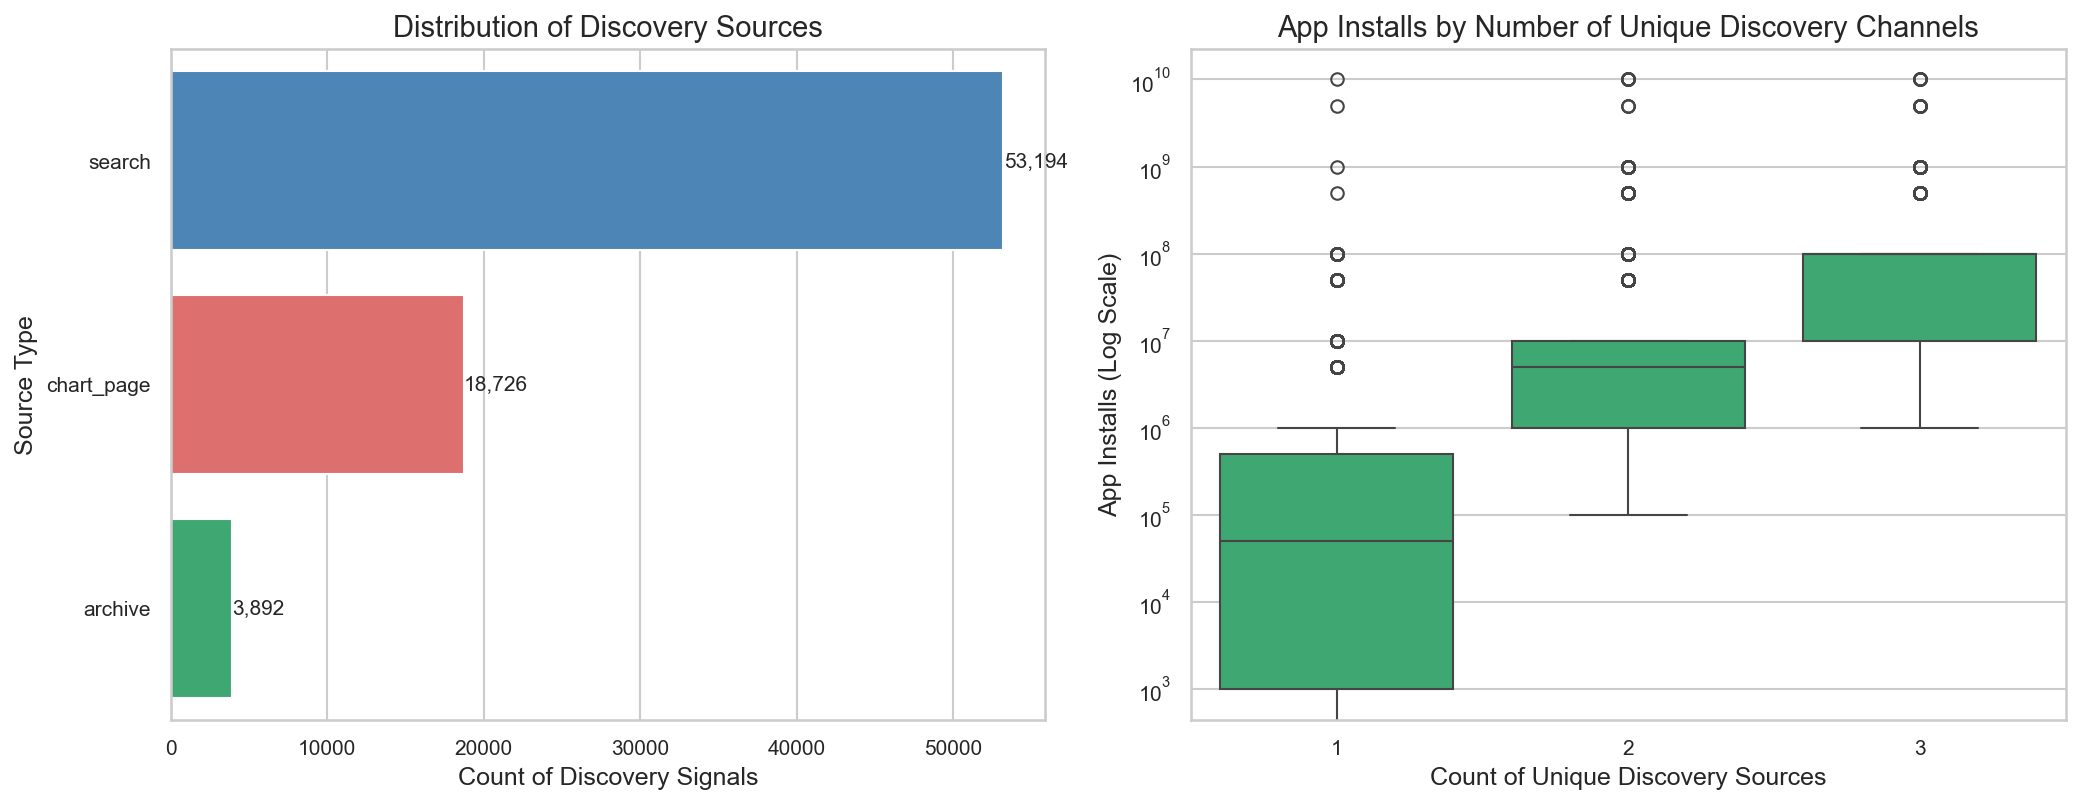

In [14]:
# Figure 6: Discovery Sources Breakdown and Source Depth
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5.5))

# Left: Discovery counts
discovery_counts = discovery['source'].value_counts()
sns.barplot(x=discovery_counts.values, y=discovery_counts.index, hue=discovery_counts.index, palette=PALETTE[:len(discovery_counts)], legend=False, ax=ax1)
ax1.set_title("Distribution of Discovery Sources")
ax1.set_xlabel("Count of Discovery Signals")
ax1.set_ylabel("Source Type")
for i, v in enumerate(discovery_counts.values):
    ax1.text(v + 10, i, f"{v:,}", va='center', fontsize=10)

# Right: Box plot of installations by unique sources count
sns.boxplot(data=app_discovery_depth, x="unique_sources", y="min_installs", color=ACCENT_COLOR, ax=ax2)
ax2.set_yscale('log')
ax2.set_title("App Installs by Number of Unique Discovery Channels")
ax2.set_xlabel("Count of Unique Discovery Sources")
ax2.set_ylabel("App Installs (Log Scale)")

plt.tight_layout()
plt.show()


# 10. Strategic Insights & Conclusions <a id="10"></a>

Based on our comprehensive analytical exploration of the 2026 Play Store data, we present the following strategic takeaways for developers, publishers, and product managers:

### 1. Monetize Smarter, Not Harder
Adding In-App Purchases (IAP) is a dominant growth lever. For paid apps, those incorporating IAPs earn a median of 50,000 installations, compared to just 3,000 for standard paid apps. Transitioning to a freemium or hybrid pricing model (e.g. ad-supported with IAP unlocks) is highly recommended for market viability.

### 2. Target Regional Hidden Gems
There is significant opportunity in localized, overseas markets. Over 300 apps which have zero or low scores in the US are highly rated in emerging markets like India or Brazil. Tailoring apps for regional interests, languages, and requirements (specifically targeting Brazil, which shows highest median installs in Shopping and Entertainment) is a proven expansion route.

### 3. Focus on Search Optimization (ASO)
Organic search keywords drive over 60-90% of app discovery signals depending on the genre. High correlation also exists between the number of discovery channels an app occupies and its install counts. Optimizing keyword listings for terms with high conversion rates (like smart utility, kundli, and education queries) is essential to break through developer concentration.
